# Household Electricity Usage Forecasting

This notebook walks through the full pipeline: loading raw smart meter data, cleaning it,
resampling to hourly intervals, filling missing hours, exploring patterns, training a
Facebook Prophet model, evaluating it, and forecasting future usage.

All the actual logic lives in the `src/` package. This notebook just calls it, step by
step, so the whole process can be reviewed and explained end to end.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project root (src/ folder not found).")

sys.path.insert(0, str(project_root))
print("Project root set to:", project_root)

Project root set to: /home/claude/electricity-usage-forecasting


## Step 1: Load Raw Data

In [2]:
from src.data_loader import load_raw_data

raw_df = load_raw_data()
print("Raw data shape:", raw_df.shape)
raw_df.head()

Raw data shape: (70368, 8)


,TYPE,DATE,START TIME,END TIME,USAGE,UNITS,COST,NOTES
0,Electric usage,10/22/2016,0:00,0:14,0.01,kWh,$0.00,NaN
1,Electric usage,10/22/2016,0:15,0:29,0.01,kWh,$0.00,NaN
2,Electric usage,10/22/2016,0:30,0:44,0.01,kWh,$0.00,NaN
3,Electric usage,10/22/2016,0:45,0:59,0.01,kWh,$0.00,NaN
4,Electric usage,10/22/2016,1:00,1:14,0.01,kWh,$0.00,NaN


## Step 2: Clean Data
Merges DATE and START TIME into one timestamp column, drops unused columns.

In [3]:
from src.data_cleaner import clean_data

cleaned_df = clean_data(raw_df)
print("Cleaned data shape:", cleaned_df.shape)
cleaned_df.head()

Note: 8 duplicate timestamps found (likely DST clock fall-back). Keeping all rows.
Cleaned data shape: (70368, 3)


,timestamp,USAGE,UNITS
0,2016-10-22 00:00:00,0.01,kWh
1,2016-10-22 00:15:00,0.01,kWh
2,2016-10-22 00:30:00,0.01,kWh
3,2016-10-22 00:45:00,0.01,kWh
4,2016-10-22 01:00:00,0.01,kWh


## Step 3: Resample to Hourly
15-minute readings are summed into hourly totals.

In [4]:
from src.resampler import resample_to_hourly

hourly_df = resample_to_hourly(cleaned_df)
print("15-min rows:", len(cleaned_df))
print("Hourly rows:", len(hourly_df))
hourly_df.head()

15-min rows: 70368
Hourly rows: 17590


,timestamp,UNITS,USAGE
0,2016-10-22 00:00:00,kWh,0.04
1,2016-10-22 01:00:00,kWh,0.04
2,2016-10-22 02:00:00,kWh,0.08
3,2016-10-22 03:00:00,kWh,0.04
4,2016-10-22 04:00:00,kWh,0.04


## Step 4: Handle Missing Timestamps
Finds and forward-fills any missing hours (Daylight Saving gaps).

In [5]:
from src.gap_handler import fill_missing_hours

gapfilled_df = fill_missing_hours(hourly_df)
print("Rows before gap-fill:", len(hourly_df))
print("Rows after gap-fill :", len(gapfilled_df))

Found 2 missing hour(s), likely U.S. Daylight Saving 'spring forward' gaps:
  - 2017-03-12 02:00:00
  - 2018-03-11 02:00:00
Missing hours filled using forward-fill/backward-fill backup.
Rows before gap-fill: 17590
Rows after gap-fill : 17592


## Step 5: EDA - Noise Reduction

Before jumping into modeling, this compares the raw 15-minute readings against the
resampled hourly totals, to visually justify why we resampled.

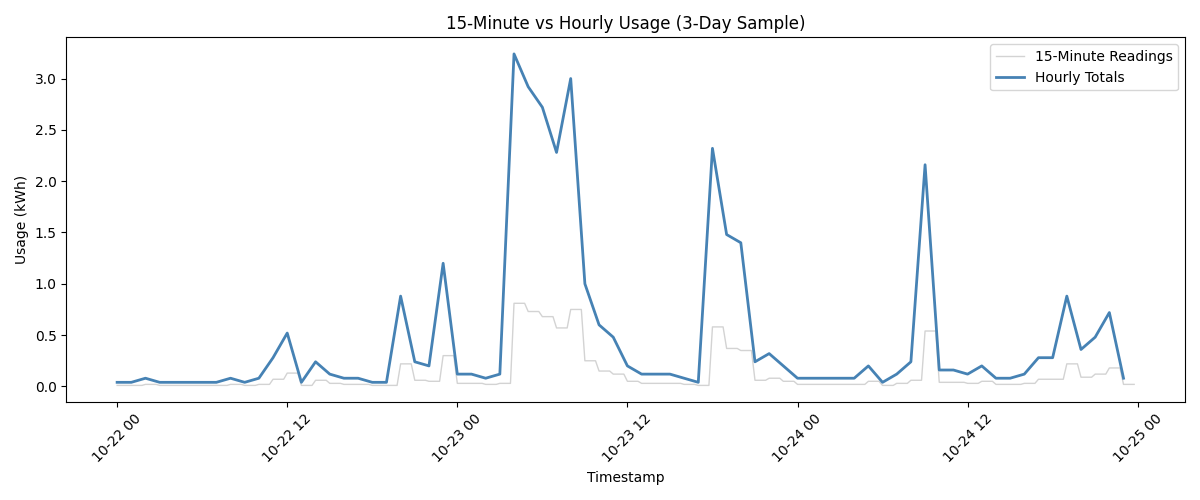

In [6]:
from src.eda import plot_noise_reduction
from src.config import FIGURES_DIR
from IPython.display import Image

plot_noise_reduction(cleaned_df, gapfilled_df)
Image(filename=str(FIGURES_DIR / "01_15min_vs_hourly.png"))

## Step 6: EDA - Daily and Weekly Usage Patterns

Peak usage hour: 19:00 (avg 0.946 kWh)


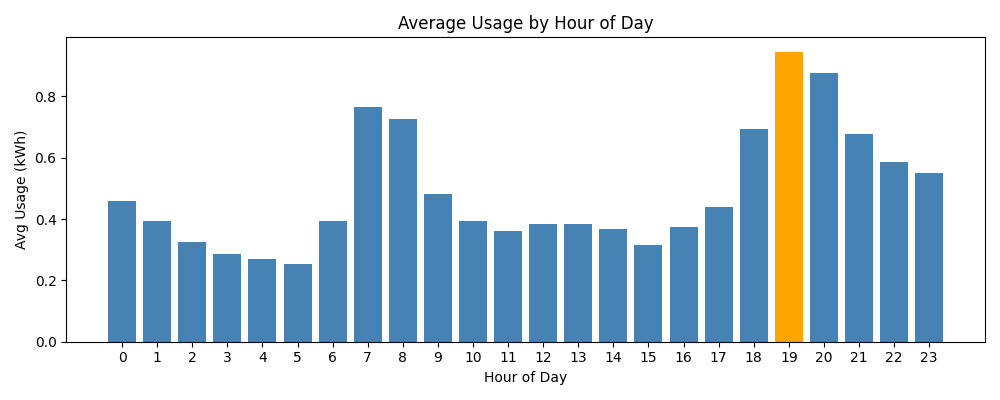

In [7]:
from src.eda import plot_hourly_pattern, plot_weekly_pattern, plot_overall_trend

peak_hour, peak_value = plot_hourly_pattern(gapfilled_df)
plot_weekly_pattern(gapfilled_df)
plot_overall_trend(gapfilled_df)

print(f"Peak usage hour: {peak_hour}:00 (avg {peak_value:.3f} kWh)")
Image(filename=str(FIGURES_DIR / "02_hourly_pattern.png"))

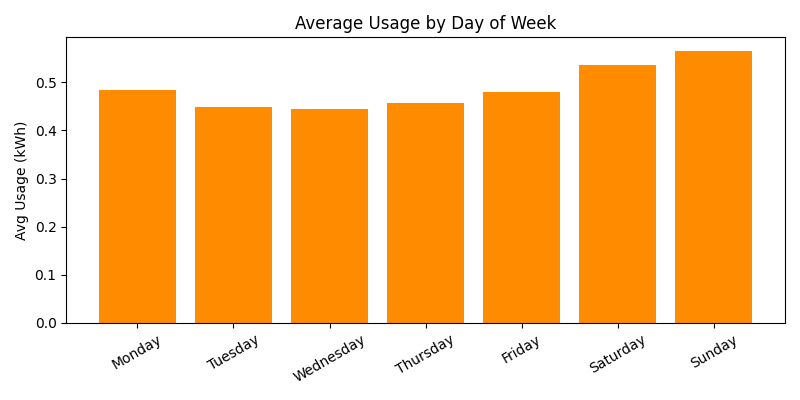

In [8]:
Image(filename=str(FIGURES_DIR / "03_weekly_pattern.png"))

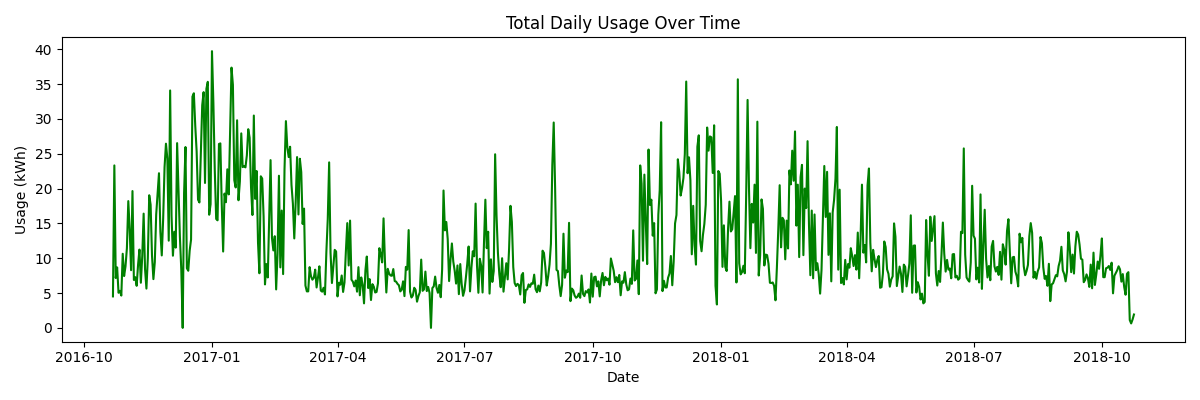

In [9]:
Image(filename=str(FIGURES_DIR / "04_overall_trend.png"))

## Step 7: Train/Test Split and Model Training

The last 7 days are held out as a test set. The model never sees these during training,
so we can check how well it predicts real, unseen data.

In [10]:
from src.train_model import split_train_test, build_and_fit_model, save_model

train_df, test_df = split_train_test(gapfilled_df)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train range:", train_df["ds"].min(), "to", train_df["ds"].max())
print("Test range :", test_df["ds"].min(), "to", test_df["ds"].max())

model = build_and_fit_model(train_df)
save_model(model)
print("Model trained and saved.")

Train rows: 17424 | Test rows: 168
Train range: 2016-10-22 00:00:00 to 2018-10-17 23:00:00
Test range : 2018-10-18 00:00:00 to 2018-10-24 23:00:00


10:40:46 - cmdstanpy - INFO - Chain [1] start processing


10:40:47 - cmdstanpy - INFO - Chain [1] done processing


Model trained and saved.


## Step 8: Evaluate the Model (Backtest)

MAE : 0.2680 kWh
RMSE: 0.3461 kWh


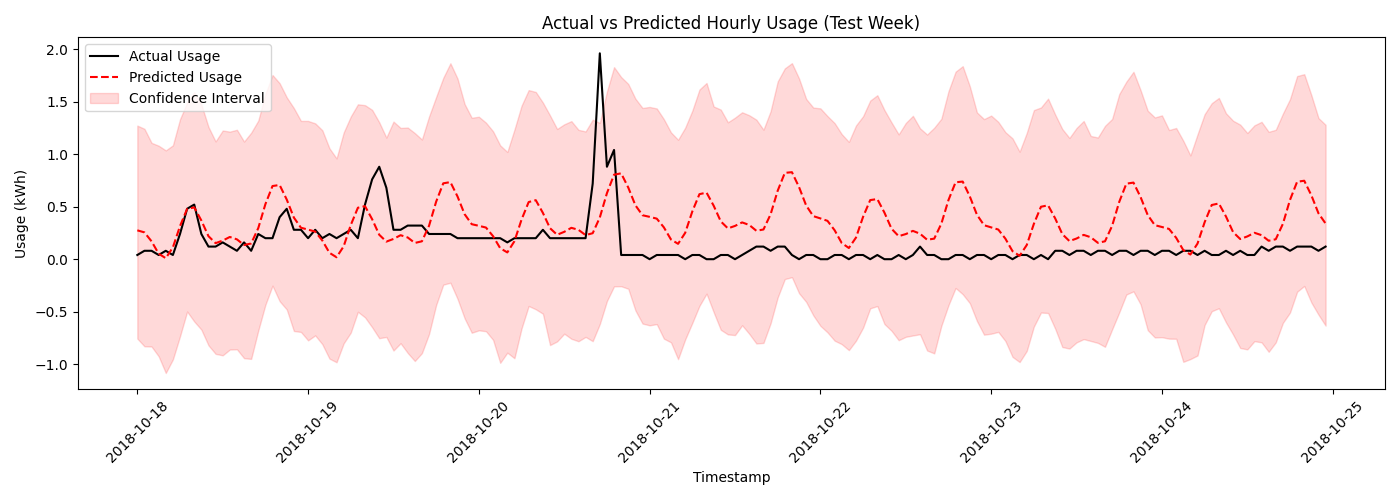

In [11]:
from src.evaluate import generate_forecast, compute_metrics, save_forecast_results, plot_actual_vs_predicted

result_df = generate_forecast(model, test_df)
metrics = compute_metrics(result_df)
save_forecast_results(result_df)
plot_actual_vs_predicted(result_df)

print(f"MAE : {metrics['MAE']:.4f} kWh")
print(f"RMSE: {metrics['RMSE']:.4f} kWh")
Image(filename=str(FIGURES_DIR / "05_actual_vs_predicted.png"))

## Step 9: Forecast Real Future Usage

This retrains on all available data (not just the pre-test-cutoff split) and predicts
real dates beyond the last recorded reading.

In [12]:
from src.forecast_future import train_on_full_data, forecast_ahead
import pandas as pd

future_model = train_on_full_data(gapfilled_df)
last_date = pd.to_datetime(gapfilled_df["timestamp"]).max()

future_forecast = forecast_ahead(future_model, last_date, days=7)
print(f"Last known data point: {last_date}")
print("\nFirst few predicted hours:")
print(future_forecast.head())
print("\nLast few predicted hours:")
print(future_forecast.tail())

10:40:48 - cmdstanpy - INFO - Chain [1] start processing


10:40:50 - cmdstanpy - INFO - Chain [1] done processing


Last known data point: 2018-10-24 23:00:00

First few predicted hours:
                   ds      yhat  yhat_lower  yhat_upper
0 2018-10-25 00:00:00  0.255575         0.0    1.351954
1 2018-10-25 01:00:00  0.236631         0.0    1.241424
2 2018-10-25 02:00:00  0.152413         0.0    1.186177
3 2018-10-25 03:00:00  0.036167         0.0    1.163958
4 2018-10-25 04:00:00  0.000000         0.0    1.035108

Last few predicted hours:
                     ds      yhat  yhat_lower  yhat_upper
163 2018-10-31 19:00:00  0.752887         0.0    1.741711
164 2018-10-31 20:00:00  0.762187         0.0    1.745793
165 2018-10-31 21:00:00  0.624572         0.0    1.681668
166 2018-10-31 22:00:00  0.454910         0.0    1.428110
167 2018-10-31 23:00:00  0.358769         0.0    1.319226


## Conclusion

- **Peak usage hour**: identified directly from the data (see Step 6 output above)
- **Model accuracy**: MAE and RMSE printed in Step 8, both in kWh, computed on a full
  unseen test week
- **Data quality handling**: duplicate timestamps from Daylight Saving "fall back" are
  kept (they represent two real hours folded into one label), and missing hours from
  "spring forward" are forward-filled
- **Future forecasting**: Step 9 shows real predictions beyond the last recorded date

An interactive Streamlit interface for this same pipeline is available in `app/app.py`.
Run it with:

```
streamlit run app/app.py
```
